In [1]:
save_data = False

In [2]:
import importlib
import PCA_law
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

importlib.reload(PCA_law)

from PCA_law import PCA_law, PCA_classifier


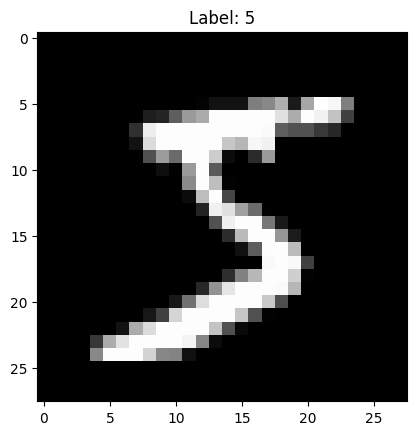

In [3]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.ToTensor()
mnist_train = datasets.MNIST(root='data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='data', train=False, download=True, transform=transform)

# Example image
img, label = mnist_train[0]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.show()


In [4]:
# Convert to NumPy arrays
X_train = np.stack([img.numpy().squeeze() for img, _ in mnist_train])
y_train = np.array([label for _, label in mnist_train])

X_test = np.stack([img.numpy().squeeze() for img, _ in mnist_test])
y_test = np.array([label for _, label in mnist_test])

print(X_train.shape, y_train.shape)  # (60000, 28, 28) (60000,)

(60000, 28, 28) (60000,)


In [5]:
Xflat = X_train.reshape(-1, 28*28)
Xflat.shape

(60000, 784)

5
10
15
20
25
30
35
40
45
50
55
60
65
70
75
80
85
90
95
100
105
110
115
120
125
130
135
140
145
150
155
160
165
170
175
180
185
190
195


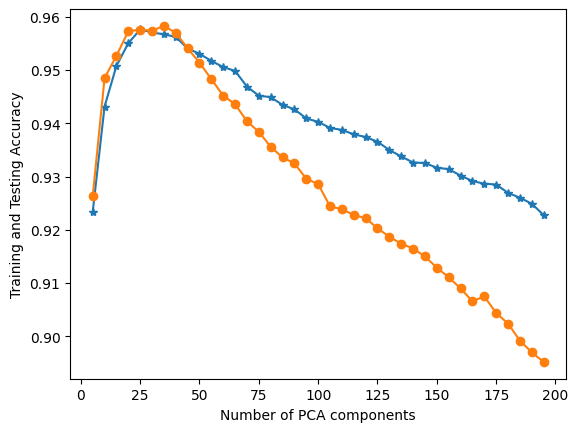

In [6]:
results = []
for n_components in range(5, 200, 5):
    print(n_components)
    pcl = PCA_classifier(n_components= n_components)
    pcl.fit(X_train.reshape(-1,28*28),y_train)
    y_pred = pcl.predict(X_train.reshape(-1,28*28))
    y_testpred = pcl.predict(X_test.reshape(-1,28*28))
    acc = accuracy_score(y_train, y_pred)
    acctest = accuracy_score(y_test, y_testpred)
    results.append((n_components, acc, acctest))
results = np.array(results)
plt.plot(results[:,0], results[:,1], "*-")
plt.plot(results[:,0], results[:,2], "o-")
plt.xlabel("Number of PCA components")
plt.ylabel("Training and Testing Accuracy")
plt.show()


In [7]:
pcl = PCA_classifier(n_components= 1)
pcl.fit(X_train.reshape(-1,28*28),y_train)
y_pred = pcl.predict(X_train.reshape(-1,28*28), ord=1)
# --- Evaluation ---
acc = accuracy_score(y_train, y_pred)
print(f"✨ PCA_law accuracy: {100*acc:.1f}%")

✨ PCA_law accuracy: 94.9%


label=5


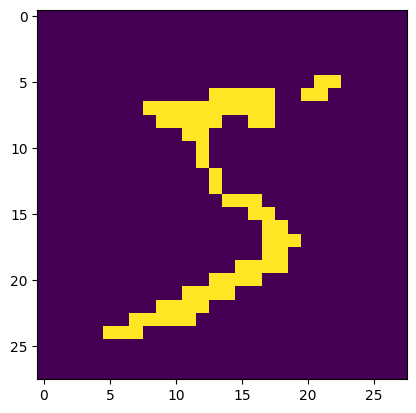

In [38]:
plt.imshow(X_train[0]>0.9)
print(f'label={y_train[0]}')

In [32]:
X0 = X_train[y_train==0]
X1 = X_train[y_train!=0]

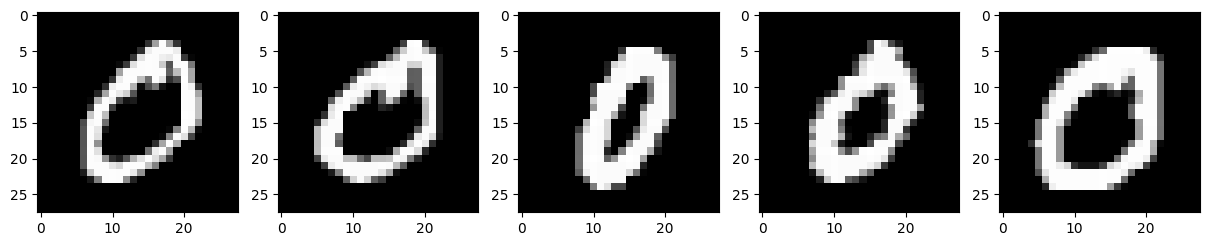

In [13]:
ncols=5
fig, ax = plt.subplots(1, ncols, figsize=(3*ncols, 3))
for i in range(ncols):
    ax[i].imshow(X0[i], cmap='gray')

In [42]:
n_components = 35
npart = 5
ndata = X0.shape[0]//npart
print('len(ndata)=', ndata )
pclaw = []
for n in range(npart):
    pclaw.append(PCA_law(n_components= n_components))
    pclaw[-1].fit(X0[n:n+ndata].reshape(-1,28*28))
    print(pclaw[-1].chi2(X0[n:n+ndata].reshape(-1,28*28)).mean())

len(ndata)= 1184
0.40878433
0.40878436
0.4087844
0.4087844
0.4087843


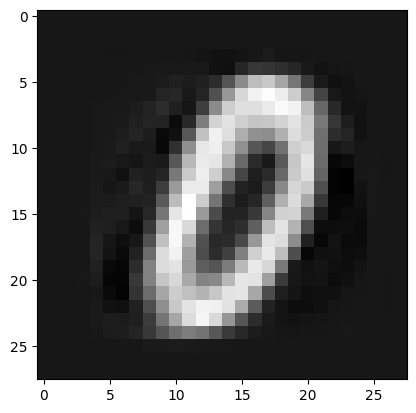

In [36]:
pp0 = pclaw[-1].compress(X0[2].reshape(-1,28*28))
xrecon = pclaw[-1].reconstruct(pp0).reshape(28,28)
plt.imshow(xrecon, cmap='gray')

In [39]:
[np.mean(pp.chi2(X0.reshape(-1,28*28), ep=1e-30)) for pp in pclaw]  

[np.float32(8.178415e+26),
 np.float32(8.178415e+26),
 np.float32(8.178415e+26),
 np.float32(8.178415e+26),
 np.float32(8.178415e+26)]

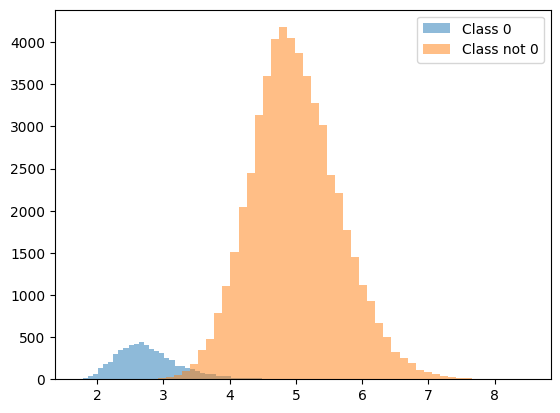

In [33]:
u = pclaw.classify(X0.reshape(-1,28*28))
v = pclaw.classify(X1.reshape(-1,28*28))
plt.hist(u, bins=50, alpha=0.5, label='Class 0')
plt.hist(v, bins=50, alpha=0.5, label='Class not 0')
plt.legend()
plt.show()